In [2]:
import scqubits
import numpy as np
from scipy.optimize import minimize

In [15]:
EJ = 8
EC = 2.5
EL = 0.5

qubit_level = 30

def get_shift(ele,Delta_ij):
    return abs(ele)**2 / Delta_ij

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x
    shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift(elements[2,ql2],evals[ql2]-evals[2]-Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [5]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.2455685626948663e-09
             x: [ 4.976e+00]
           nit: 13
          nfev: 26
 final_simplex: (array([[ 4.976e+00],
                       [ 4.976e+00]]), array([ 2.246e-09,  4.163e-07]))
Optimal solution: [4.97589111]
Objective value: 2.2455685626948663e-09


In [16]:
from utils import *

max overlap^2 0.003592586617243998 below threshold for dressed state 813 with eval 189.49454803137704
max overlap^2 0.004529980256803493 below threshold for dressed state 824 with eval 192.84325339046612
max overlap^2 0.0058296059789899385 below threshold for dressed state 828 with eval 194.509521924595
max overlap^2 0.005308870791926583 below threshold for dressed state 834 with eval 196.3839266857958
max overlap^2 0.0059636770908393635 below threshold for dressed state 842 with eval 200.0243467765785
max overlap^2 0.006728212818814965 below threshold for dressed state 848 with eval 201.8121023507147
max overlap^2 0.006544352735695918 below threshold for dressed state 853 with eval 203.70577180363085
max overlap^2 0.006883685359801684 below threshold for dressed state 861 with eval 207.39633190185236
max overlap^2 0.006316743238743011 below threshold for dressed state 865 with eval 208.90552477314566
max overlap^2 0.0017004442418953902 below threshold for dressed state 869 with eval 2

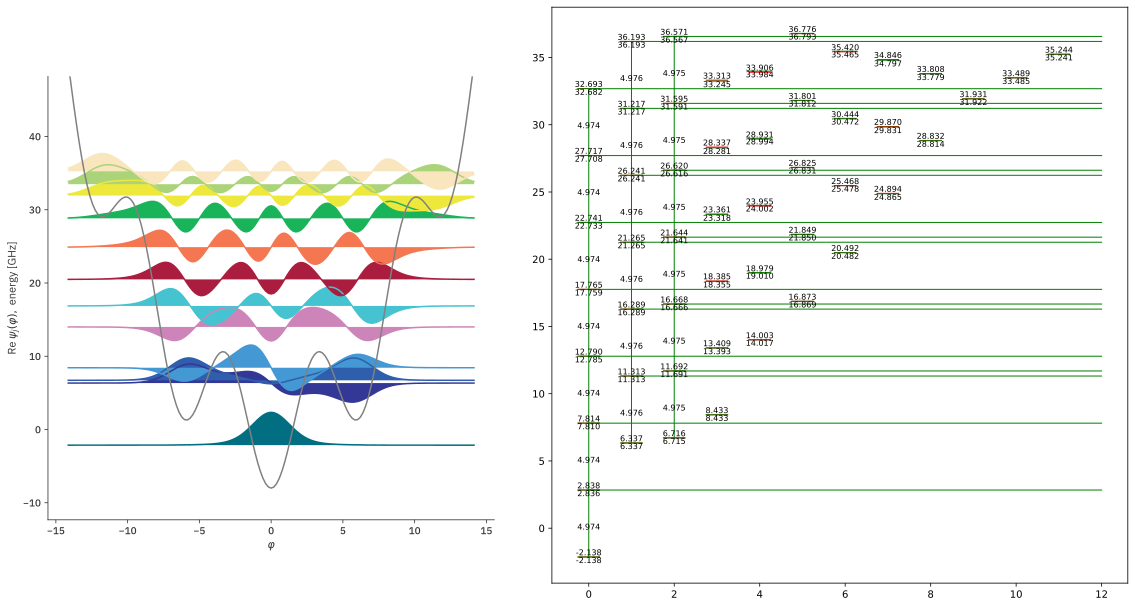

In [20]:
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = 0.15,
    qubit_level = 30,
    osc_level = 30,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(30) for ol in range(30) ]
    )


energies=  system.hilbertspace.eigenvals(900)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,29):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,10):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

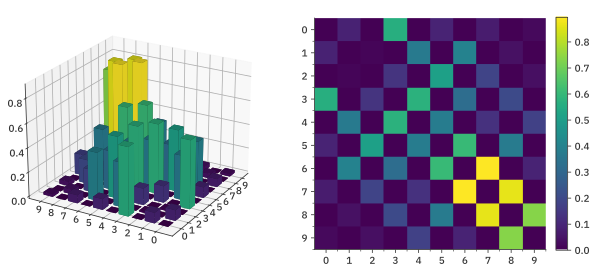

In [6]:
system.qbt.plot_matrixelements('n_operator',evals_count = 10)